<a href="https://colab.research.google.com/github/radwaelreedy/ml-data-analysis/blob/main/logistics-regression%20/%20Assignment_Logistics_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df = pd.read_csv("/content/diabetes (1).csv")

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df['Outcome'].unique()

array([1, 0])

In [ ]:
x = df.iloc[:, 0:8].values
y = df.iloc[:, 8].values

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y , test_size= 0.2, stratify=y, random_state =42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train =sc.fit_transform(x_train)
x_test =sc.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train,y_train)

LogisticRegression()

In [ ]:
train_pred = clf.predict(x_train)
test_pred = clf.predict(x_test)

In [ ]:
tarin_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)

In [ ]:
print("train score",tarin_score * 100)
print("test score",test_score *100)

train score 79.15309446254072
test score 71.42857142857143


In [ ]:
sum(y_test ==test_pred)/len(y_test)

np.float64(0.7142857142857143)

In [ ]:
len(y_test)

154

In [ ]:
len(x_train)

614

In [ ]:
BloodPressure =[[70, 80, 50, 71, 30, 60, 40,50]]
scaled_result=sc.transform(BloodPressure)
res=clf.predict(scaled_result)
res

array([1])

In [ ]:
len(y_test)

154

In [ ]:
len(y_test[y_test == 1])

54

In [ ]:
len(y_test[y_test == 0])

100

In [ ]:
clf.classes_

array([0, 1])

In [ ]:
import numpy as np

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
Confusion_matrix = confusion_matrix(y_test, test_pred)
Confusion_matrix

array([[82, 18],
       [26, 28]])

In [ ]:
from sklearn import metrics

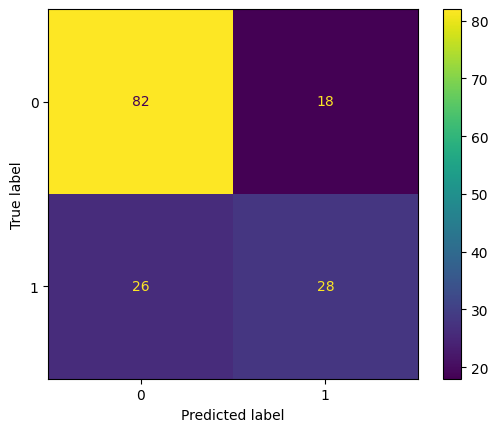

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix= Confusion_matrix, display_labels=[0,1])
cm_display.plot()
plt.show ()

In [ ]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



In [ ]:
y_pred_proba= clf.predict_proba(x_test)
y_pred_proba[0:5]

array([[0.38332647, 0.61667353],
       [0.88721884, 0.11278116],
       [0.72746042, 0.27253958],
       [0.71331836, 0.28668164],
       [0.99551857, 0.00448143]])

In [ ]:

pred1 =np.argmax(y_pred_proba, axis =1)
pred1

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0])

In [ ]:
binary_logloss = (-y_test * np.log(y_pred_proba[:,1]) - (1 - y_test) * np.log(1 - y_pred_proba[:,1])).mean()
binary_logloss

np.float64(0.49447687444769367)

In [ ]:
from keras.utils import to_categorical
y_test_cat=to_categorical(y_test)

In [ ]:
from sklearn.metrics import log_loss

loss_sckit=log_loss(y_test,y_pred_proba)
loss_sckit

0.49447687444769367

In [ ]:
multi_class_logloss = -np.sum(y_test_cat * np.log(y_pred_proba), axis=1).mean()
multi_class_logloss

np.float64(0.49447687444769367)

In [ ]:
w=clf.coef_
w=w.ravel()
w

array([ 0.37317821,  1.14415127, -0.19763683,  0.06653497, -0.12730823,
        0.71389341,  0.25552675,  0.18417899])

In [ ]:
b = clf.intercept_
b

array([-0.87496049])

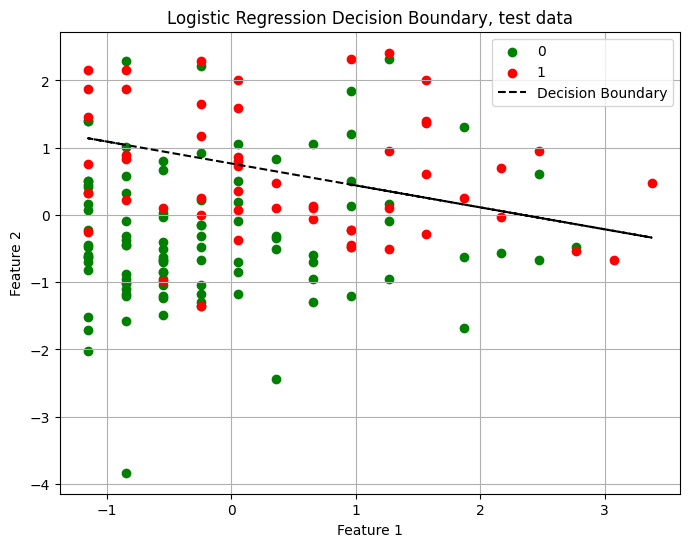

In [ ]:
plt.figure(figsize=(8, 6))
#plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='bwr', edgecolor='k', s=60)
plt.scatter(x_test[:,0][y_test==0], x_test[:,1][y_test==0], label="0",  c='green')
plt.scatter(x_test[:,0][y_test==1], x_test[:,1][y_test==1], label="1",  c='red')
yy = -(w[0] * x_test[:, 0] + b) / w[1]   # wx+b=0  , w1x1+w2x2+b=0, x2= -(w1x1+b)/w2
plt.plot(x_test[:, 0], yy, 'k--', label='Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary, test data' )
plt.legend()
plt.grid(True)


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
z=np.dot(x_test,w)+b
p = sigmoid(z)
pred_manually=(p >= 0.5).astype(int)
sum(test_pred==pred_manually)

np.int64(154)

In [ ]:
p[0:5]

array([0.61667353, 0.11278116, 0.27253958, 0.28668164, 0.00448143])

In [ ]:
y_pred_proba[0:5]

array([[0.38332647, 0.61667353],
       [0.88721884, 0.11278116],
       [0.72746042, 0.27253958],
       [0.71331836, 0.28668164],
       [0.99551857, 0.00448143]])